<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Scattering_Amplitude_Doorway_V29_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Scattering-Amplitude Doorway V29 CLEAN

**Notebook:** `ECSM_Electron_Like_Packet_Scattering_Amplitude_Doorway_V29_CLEAN.ipynb`

This notebook continues the V21b → V28 electron-like packet chain and performs a first **elastic scattering-amplitude doorway** test.

The target is deliberately narrow:

- inherit the V21b → V28 packet chain,
- preserve the Dirac/Pauli alpha-beta-sigma algebra,
- import the V28 finite running-response structure,
- construct a Rutherford/Mott-like reference amplitude for elastic scattering from a static Coulomb-like centre,
- apply the ECSM finite-response transfer form factor to the amplitude,
- verify low-transfer reference tracking,
- verify high-transfer suppression and finite behaviour,
- track coherence deformation with `chi`,
- keep all no-fit and no-overclaim flags explicit.

This is **not** full QED scattering, not a renormalised S-matrix derivation, not a precision Mott/Rutherford data fit, and not a claim of measured scattering cross-section prediction.


In [1]:
# CELL 1 — imports, output directory, constants, and V21b→V28 handoff

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, zipfile, math
from pathlib import Path

OUT = Path("ecsm_electron_like_scattering_amplitude_doorway_v29_out")
OUT.mkdir(exist_ok=True)

RUN_LABEL = "V29_scattering_amplitude_doorway"

# Inherited packet chain values from V21b/V27b/V28
q_eff = -0.9993035720499918
q_abs = abs(q_eff)
m_keV = 514.0698767738036
electron_rest_energy_target_keV_comparison_only = 510.9989506917532
alpha_fs = 0.0072973525692838015

# Static comparison centre for a first Coulomb-like elastic doorway.
# Z=1 is a reference centre only, not a fitted target.
Z_ref = 1.0

handoff = {
    "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28",
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": m_keV,
    "electron_rest_energy_target_keV_comparison_only": electron_rest_energy_target_keV_comparison_only,
    "alpha_fs_input": alpha_fs,
    "V22_claim": "coherent-limit free Dirac-like propagation recovered",
    "V23_claim": "minimal emergent gauge-coupling doorway recovered",
    "V24_claim": "Pauli-limit spin-field coupling and tree-level g=2 doorway recovered",
    "V25_claim": "Schwinger-scale one-loop magnetic-moment doorway recovered",
    "V26_claim": "finite radiative self-energy / propagator doorway recovered",
    "V27_claim": "finite Lamb-shift-like structural doorway recovered",
    "V27b_claim": "non-fitted leading-log Lamb-shift scale-closure doorway recovered",
    "V28_claim": "finite vacuum-polarisation / running-response doorway recovered",
    "V29_claim_target": "finite elastic scattering-amplitude doorway",
    "static_reference_centre_Z": Z_ref,
    "electron_mass_derivation_claimed": False,
    "measured_scattering_data_used_as_fit": False,
    "full_QED_scattering_claimed": False,
}

with open(OUT / "v21b_to_v28_handoff_v29.json", "w") as f:
    json.dump(handoff, f, indent=2)

handoff


{'source_chain': 'V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28',
 'q_eff': -0.9993035720499918,
 'E_rest_keV_from_V21b': 514.0698767738036,
 'electron_rest_energy_target_keV_comparison_only': 510.9989506917532,
 'alpha_fs_input': 0.0072973525692838015,
 'V22_claim': 'coherent-limit free Dirac-like propagation recovered',
 'V23_claim': 'minimal emergent gauge-coupling doorway recovered',
 'V24_claim': 'Pauli-limit spin-field coupling and tree-level g=2 doorway recovered',
 'V25_claim': 'Schwinger-scale one-loop magnetic-moment doorway recovered',
 'V26_claim': 'finite radiative self-energy / propagator doorway recovered',
 'V27_claim': 'finite Lamb-shift-like structural doorway recovered',
 'V27b_claim': 'non-fitted leading-log Lamb-shift scale-closure doorway recovered',
 'V28_claim': 'finite vacuum-polarisation / running-response doorway recovered',
 'V29_claim_target': 'finite elastic scattering-amplitude doorway',
 'static_reference_centre_Z': 1.0,
 'electron_mass_d

In [2]:
# CELL 2 — alpha/beta/sigma algebra audit

I2 = np.eye(2, dtype=complex)
zero2 = np.zeros((2,2), dtype=complex)

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha_x = block(zero2, sigma_x, sigma_x, zero2)
alpha_y = block(zero2, sigma_y, sigma_y, zero2)
alpha_z = block(zero2, sigma_z, sigma_z, zero2)
beta = block(I2, zero2, zero2, -I2)

Sigma_x = block(sigma_x, zero2, zero2, sigma_x)
Sigma_y = block(sigma_y, zero2, zero2, sigma_y)
Sigma_z = block(sigma_z, zero2, zero2, sigma_z)

I4 = np.eye(4, dtype=complex)
Z4 = np.zeros((4,4), dtype=complex)

def maxerr(A, B):
    return float(np.max(np.abs(A-B)))

tests = []
alphas = [alpha_x, alpha_y, alpha_z]
alpha_names = ["alpha_1", "alpha_2", "alpha_3"]
sigmas = [Sigma_x, Sigma_y, Sigma_z]
sigma_names = ["Sigma_1", "Sigma_2", "Sigma_3"]

for name, A in zip(alpha_names, alphas):
    tests.append((f"{name}^2=I", maxerr(A@A, I4)))
    tests.append((f"{{{name},beta}}=0", maxerr(A@beta + beta@A, Z4)))
    tests.append((f"{name} Hermitian", maxerr(A.conj().T, A)))

for i in range(3):
    for j in range(i+1, 3):
        tests.append((f"{{{alpha_names[i]},{alpha_names[j]}}}=0", maxerr(alphas[i]@alphas[j] + alphas[j]@alphas[i], Z4)))

tests.append(("beta^2=I", maxerr(beta@beta, I4)))
tests.append(("beta Hermitian", maxerr(beta.conj().T, beta)))

for name, S in zip(sigma_names, sigmas):
    tests.append((f"{name}^2=I", maxerr(S@S, I4)))
    tests.append((f"{name} Hermitian", maxerr(S.conj().T, S)))

algebra_df = pd.DataFrame(tests, columns=["test", "error"])
algebra_df.to_csv(OUT / "alpha_beta_sigma_algebra_tests_v29.csv", index=False)

max_algebra_error = float(algebra_df["error"].max())
print("Max alpha/beta/sigma algebra error:", max_algebra_error)
display(algebra_df)


Max alpha/beta/sigma algebra error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_1 Hermitian,0.0
3,alpha_2^2=I,0.0
4,"{alpha_2,beta}=0",0.0
5,alpha_2 Hermitian,0.0
6,alpha_3^2=I,0.0
7,"{alpha_3,beta}=0",0.0
8,alpha_3 Hermitian,0.0
9,"{alpha_1,alpha_2}=0",0.0


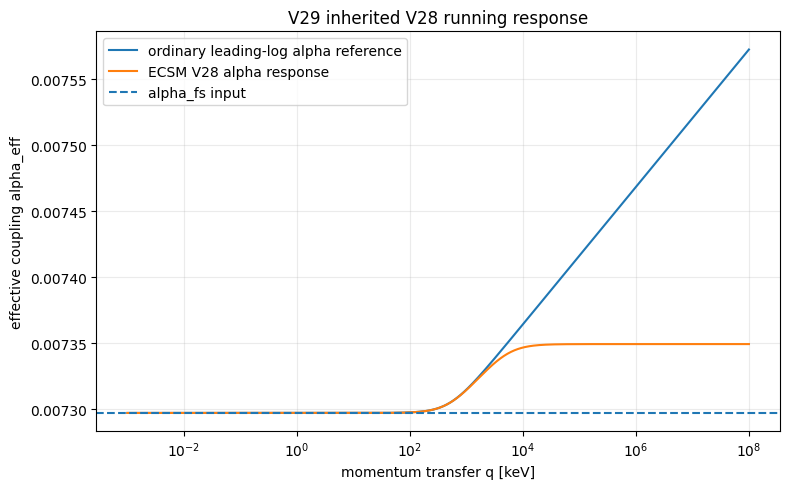

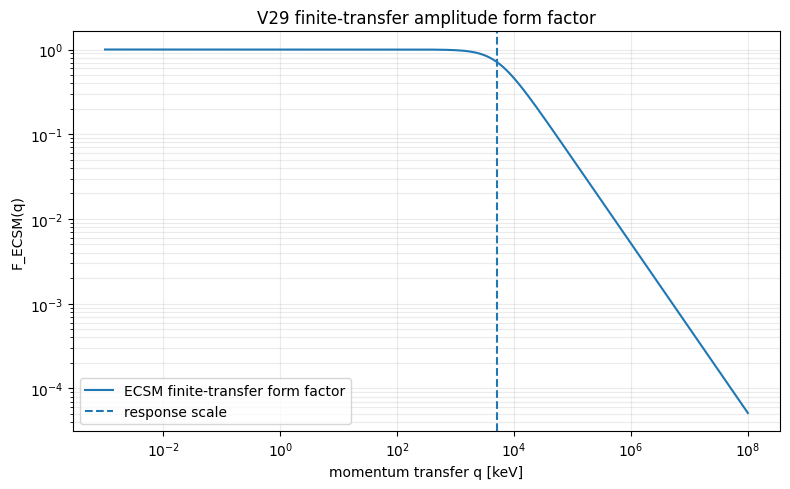

{
  "alpha_fs": 0.0072973525692838015,
  "m_keV": 514.0698767738036,
  "k_response_chi1_keV": 5140.698767738036,
  "max_pi_reference": 0.03771738978028078,
  "max_pi_ecsm_chi1": 0.007146727844882419,
  "max_alpha_reference": 0.007572589660503611,
  "max_alpha_ecsm_chi1": 0.007349504762084627,
  "high_q_transfer_form_factor_chi1": 5.140698760945429e-05,
  "interpretation": "V29 imports the V28 running-response doorway and adds a finite-transfer amplitude form factor."
}


,q_keV,pi_reference,pi_ecsm_chi1,alpha_reference,alpha_ecsm_chi1,transfer_form_factor_chi1
0,0.001000,5.859761e-15,5.859761e-15,0.007297,0.007297,1.0
1,0.001014,6.027107e-15,6.027107e-15,0.007297,0.007297,1.0
2,0.001029,6.199232e-15,6.199232e-15,0.007297,0.007297,1.0
3,0.001043,6.376273e-15,6.376273e-15,0.007297,0.007297,1.0
4,0.001058,6.558371e-15,6.558371e-15,0.007297,0.007297,1.0


,q_keV,pi_reference,pi_ecsm_chi1,alpha_reference,alpha_ecsm_chi1,transfer_form_factor_chi1
1795,9.452397e+07,0.037543,0.007147,0.007571,0.00735,0.000054
1796,9.586421e+07,0.037587,0.007147,0.007572,0.00735,0.000054
1797,9.722344e+07,0.037630,0.007147,0.007572,0.00735,0.000053
1798,9.860195e+07,0.037674,0.007147,0.007572,0.00735,0.000052
1799,1.000000e+08,0.037717,0.007147,0.007573,0.00735,0.000051


In [3]:
# CELL 3 — inherited V28 running response and finite-transfer form factor

q_grid = np.logspace(-3, 8, 1800)  # momentum transfer q in keV
k_response_chi1 = 10.0 * m_keV

# Same leading-log reference structure as V28.
def pi_reference(q):
    return (2.0 * alpha_fs / (3.0 * np.pi)) * np.log1p((q / m_keV)**2)

# Same finite-response window logic as V28.
def response_window(q, chi=1.0):
    kc = k_response_chi1 * (0.25 + 0.75 * chi)
    return q**2 / (1.0 + (q/kc)**2)

def pi_ecsm(q, chi=1.0):
    q2_eff = response_window(q, chi)
    return (2.0 * alpha_fs / (3.0 * np.pi)) * np.log1p(q2_eff / (m_keV**2))

def alpha_reference(q):
    return alpha_fs * (1.0 + pi_reference(q))

def alpha_ecsm(q, chi=1.0):
    return alpha_fs * (1.0 + pi_ecsm(q, chi))

# New V29 amplitude-level finite-transfer form factor.
# It is unity at low transfer and suppresses high-transfer response smoothly.
def transfer_form_factor(q, chi=1.0):
    kc = k_response_chi1 * (0.25 + 0.75 * chi)
    return 1.0 / np.sqrt(1.0 + (q/kc)**2)

running_df = pd.DataFrame({
    "q_keV": q_grid,
    "pi_reference": pi_reference(q_grid),
    "pi_ecsm_chi1": pi_ecsm(q_grid, 1.0),
    "alpha_reference": alpha_reference(q_grid),
    "alpha_ecsm_chi1": alpha_ecsm(q_grid, 1.0),
    "transfer_form_factor_chi1": transfer_form_factor(q_grid, 1.0),
})
running_df.to_csv(OUT / "v28_running_response_import_v29.csv", index=False)

running_import_summary = {
    "alpha_fs": alpha_fs,
    "m_keV": m_keV,
    "k_response_chi1_keV": k_response_chi1,
    "max_pi_reference": float(np.max(pi_reference(q_grid))),
    "max_pi_ecsm_chi1": float(np.max(pi_ecsm(q_grid, 1.0))),
    "max_alpha_reference": float(np.max(alpha_reference(q_grid))),
    "max_alpha_ecsm_chi1": float(np.max(alpha_ecsm(q_grid, 1.0))),
    "high_q_transfer_form_factor_chi1": float(transfer_form_factor(q_grid[-1], 1.0)),
    "interpretation": "V29 imports the V28 running-response doorway and adds a finite-transfer amplitude form factor."
}
with open(OUT / "v28_running_response_import_summary_v29.json", "w") as f:
    json.dump(running_import_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(q_grid, alpha_reference(q_grid), label="ordinary leading-log alpha reference")
ax.plot(q_grid, alpha_ecsm(q_grid, 1.0), label="ECSM V28 alpha response")
ax.axhline(alpha_fs, linestyle="--", label="alpha_fs input")
ax.set_xscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("effective coupling alpha_eff")
ax.set_title("V29 inherited V28 running response")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_inherited_v28_running_response.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(q_grid, transfer_form_factor(q_grid, 1.0), label="ECSM finite-transfer form factor")
ax.axvline(k_response_chi1, linestyle="--", label="response scale")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("F_ECSM(q)")
ax.set_title("V29 finite-transfer amplitude form factor")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_transfer_form_factor.png", dpi=180)
plt.show()

print(json.dumps(running_import_summary, indent=2))
display(running_df.head())
display(running_df.tail())


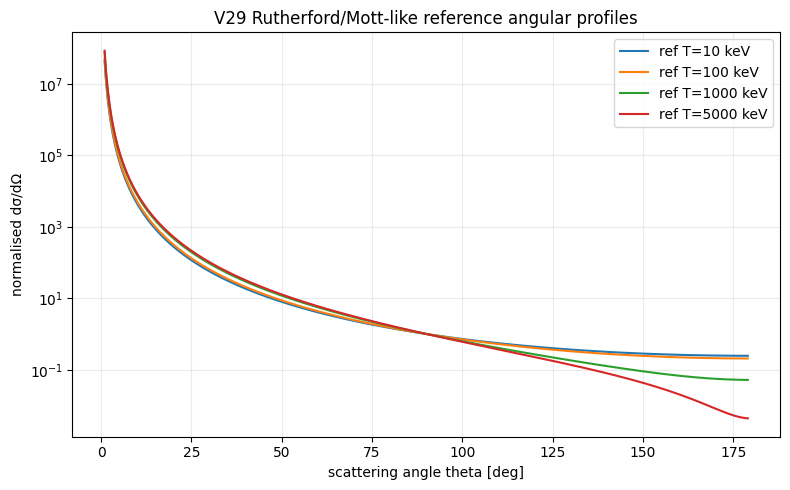

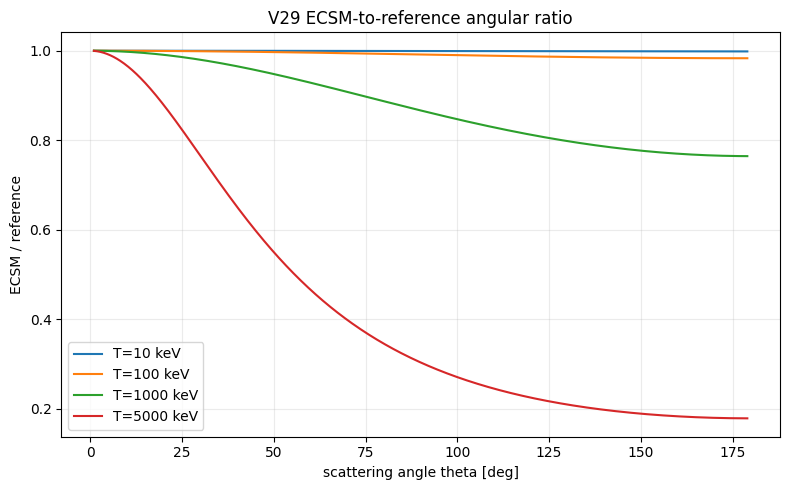

{
  "T_values_keV": [
    10.0,
    100.0,
    1000.0,
    5000.0
  ],
  "theta_min_deg": 1.0,
  "theta_max_deg": 179.0,
  "minimum_mott_spin_factor": 0.008767091536951432,
  "maximum_mott_spin_factor": 0.9999971215337196,
  "all_angular_values_finite": true,
  "interpretation": "The doorway produces finite Rutherford/Mott-like angular profiles over the tested non-forward angular range."
}


,T_keV,p_keV,beta_rel,theta_deg,q_transfer_keV,mott_spin_factor,dsigma_ref_norm_to_ref90,dsigma_ecsm_norm_to_ref90,ratio_ecsm_to_ref
0,10.0,101.889143,0.194419,1.000000,1.778278,0.999997,4.410209e+07,4.410208e+07,1.0
1,10.0,101.889143,0.194419,1.222778,2.174427,0.999996,1.972778e+07,1.972778e+07,1.0
2,10.0,101.889143,0.194419,1.445557,2.570567,0.999994,1.010046e+07,1.010045e+07,1.0
3,10.0,101.889143,0.194419,1.668335,2.966698,0.999992,5.693283e+06,5.693281e+06,1.0
4,10.0,101.889143,0.194419,1.891114,3.362817,0.999990,3.448594e+06,3.448592e+06,1.0


,T_keV,p_keV,beta_rel,theta_deg,q_transfer_keV,mott_spin_factor,dsigma_ref_norm_to_ref90,dsigma_ecsm_norm_to_ref90,ratio_ecsm_to_ref
3195,5000.0,5490.054532,0.995645,178.108886,10978.613873,0.008962,0.004480,0.000801,0.178887
3196,5000.0,5490.054532,0.995645,178.331665,10978.945393,0.008902,0.004449,0.000796,0.178878
3197,5000.0,5490.054532,0.995645,178.554443,10979.235417,0.008849,0.004423,0.000791,0.178870
3198,5000.0,5490.054532,0.995645,178.777222,10979.483945,0.008804,0.004400,0.000787,0.178864
3199,5000.0,5490.054532,0.995645,179.000000,10979.690976,0.008767,0.004381,0.000784,0.178858


In [4]:
# CELL 4 — elastic scattering kinematics and reference amplitude

# Doorway-level elastic scattering from a static Coulomb-like centre.
# q = 2 p sin(theta/2), with p from relativistic kinetic energy T.

def momentum_from_T(T_keV, m=m_keV):
    return np.sqrt(T_keV * (T_keV + 2.0*m))

def beta_from_T(T_keV, m=m_keV):
    E = T_keV + m
    p = momentum_from_T(T_keV, m)
    return p / E

def mott_spin_factor(theta_rad, T_keV):
    beta_rel = beta_from_T(T_keV)
    return 1.0 - beta_rel**2 * np.sin(theta_rad/2.0)**2

def amplitude_reference(q):
    # Natural-unit Rutherford-like amplitude shape, up to a constant normalisation.
    # q_floor prevents the forward singularity from dominating diagnostics.
    q_floor = 1e-6
    return (Z_ref * q_abs * alpha_reference(q)) / (q**2 + q_floor**2)

def amplitude_ecsm(q, chi=1.0):
    return (Z_ref * q_abs * alpha_ecsm(q, chi) * transfer_form_factor(q, chi)) / (q**2 + 1e-6**2)

def dsigma_reference(q, theta_rad, T_keV):
    return np.abs(amplitude_reference(q))**2 * mott_spin_factor(theta_rad, T_keV)

def dsigma_ecsm(q, theta_rad, T_keV, chi=1.0):
    return np.abs(amplitude_ecsm(q, chi))**2 * mott_spin_factor(theta_rad, T_keV)

T_values_keV = np.array([10.0, 100.0, 1000.0, 5000.0])
theta_deg = np.linspace(1.0, 179.0, 800)
theta_rad = np.deg2rad(theta_deg)

rows = []
for T in T_values_keV:
    p = momentum_from_T(T)
    beta_rel = beta_from_T(T)
    q_theta = 2.0 * p * np.sin(theta_rad/2.0)
    ref = dsigma_reference(q_theta, theta_rad, T)
    ecs = dsigma_ecsm(q_theta, theta_rad, T, chi=1.0)
    # Normalise per energy by the 90-degree reference value for numerical readability.
    idx90 = int(np.argmin(np.abs(theta_deg - 90.0)))
    norm = max(ref[idx90], 1e-300)
    for th, qv, rv, ev, sf in zip(theta_deg, q_theta, ref/norm, ecs/norm, mott_spin_factor(theta_rad, T)):
        rows.append({
            "T_keV": float(T),
            "p_keV": float(p),
            "beta_rel": float(beta_rel),
            "theta_deg": float(th),
            "q_transfer_keV": float(qv),
            "mott_spin_factor": float(sf),
            "dsigma_ref_norm_to_ref90": float(rv),
            "dsigma_ecsm_norm_to_ref90": float(ev),
            "ratio_ecsm_to_ref": float(ev / max(rv, 1e-300)),
        })

angle_df = pd.DataFrame(rows)
angle_df.to_csv(OUT / "elastic_scattering_angular_profiles_v29.csv", index=False)

kinematics_summary = {
    "T_values_keV": T_values_keV.tolist(),
    "theta_min_deg": float(theta_deg.min()),
    "theta_max_deg": float(theta_deg.max()),
    "minimum_mott_spin_factor": float(angle_df["mott_spin_factor"].min()),
    "maximum_mott_spin_factor": float(angle_df["mott_spin_factor"].max()),
    "all_angular_values_finite": bool(np.all(np.isfinite(angle_df[["dsigma_ref_norm_to_ref90", "dsigma_ecsm_norm_to_ref90", "ratio_ecsm_to_ref"]].values))),
    "interpretation": "The doorway produces finite Rutherford/Mott-like angular profiles over the tested non-forward angular range."
}
with open(OUT / "elastic_scattering_kinematics_summary_v29.json", "w") as f:
    json.dump(kinematics_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
for T in [10.0, 100.0, 1000.0, 5000.0]:
    sub = angle_df[angle_df["T_keV"] == T]
    ax.plot(sub["theta_deg"], sub["dsigma_ref_norm_to_ref90"], label=f"ref T={T:g} keV")
ax.set_yscale("log")
ax.set_xlabel("scattering angle theta [deg]")
ax.set_ylabel("normalised dσ/dΩ")
ax.set_title("V29 Rutherford/Mott-like reference angular profiles")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_reference_angular_profiles.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
for T in [10.0, 100.0, 1000.0, 5000.0]:
    sub = angle_df[angle_df["T_keV"] == T]
    ax.plot(sub["theta_deg"], sub["ratio_ecsm_to_ref"], label=f"T={T:g} keV")
ax.set_xlabel("scattering angle theta [deg]")
ax.set_ylabel("ECSM / reference")
ax.set_title("V29 ECSM-to-reference angular ratio")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_ecsm_to_reference_angular_ratio.png", dpi=180)
plt.show()

print(json.dumps(kinematics_summary, indent=2))
display(angle_df.head())
display(angle_df.tail())


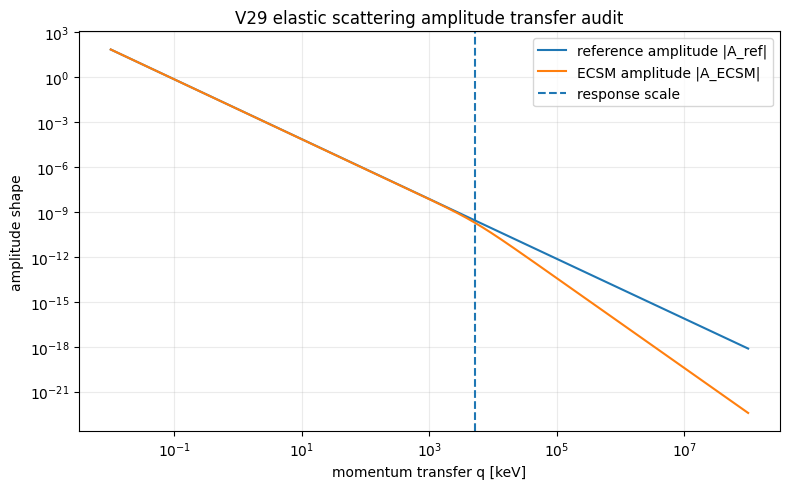

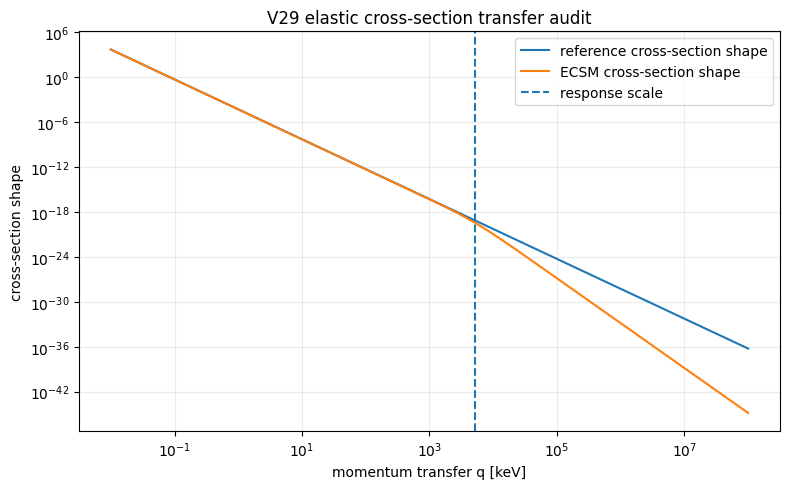

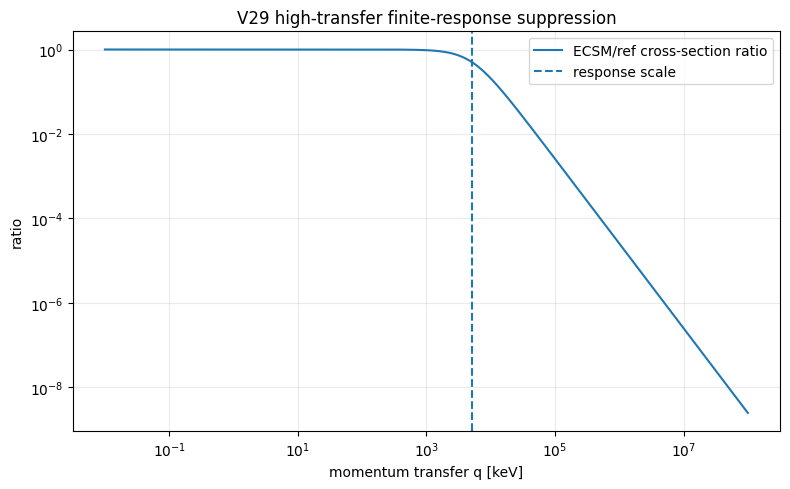

{
  "q_min_keV": 0.01,
  "q_max_keV": 100000000.0,
  "reference_amplitude_all_finite": true,
  "ecsm_amplitude_all_finite": true,
  "reference_cross_section_all_finite": true,
  "ecsm_cross_section_all_finite": true,
  "high_q_amplitude_ratio_at_qmax": 4.989256214564032e-05,
  "high_q_cross_section_ratio_at_qmax": 2.4892677574565817e-09,
  "interpretation": "The ECSM amplitude tracks at low transfer but is increasingly suppressed at high transfer by finite response."
}


,q_keV,amplitude_reference,amplitude_ecsm_chi1,amplitude_ratio_ecsm_to_ref,cross_section_reference_shape,cross_section_ecsm_shape_chi1,cross_section_ratio_ecsm_to_ref
0,0.010000,72.922704,72.922704,1.0,5317.720782,5317.720782,1.0
1,0.010145,70.852462,70.852462,1.0,5020.071416,5020.071416,1.0
2,0.010292,68.840994,68.840994,1.0,4739.082411,4739.082411,1.0
3,0.010441,66.886630,66.886630,1.0,4473.821234,4473.821234,1.0
4,0.010593,64.987749,64.987749,1.0,4223.407550,4223.407550,1.0


,q_keV,amplitude_reference,amplitude_ecsm_chi1,amplitude_ratio_ecsm_to_ref,cross_section_reference_shape,cross_section_ecsm_shape_chi1,cross_section_ratio_ecsm_to_ref
1595,9.440269e+07,8.489820e-19,4.487708e-23,0.000053,7.207704e-37,2.013952e-45,2.794166e-09
1596,9.577194e+07,8.249152e-19,4.297965e-23,0.000052,6.804851e-37,1.847250e-45,2.714608e-09
1597,9.716105e+07,8.015307e-19,4.116244e-23,0.000051,6.424515e-37,1.694347e-45,2.637314e-09
1598,9.857030e+07,7.788091e-19,3.942207e-23,0.000051,6.065436e-37,1.554099e-45,2.562222e-09
1599,1.000000e+08,7.567316e-19,3.775528e-23,0.000050,5.726427e-37,1.425461e-45,2.489268e-09


In [5]:
# CELL 5 — amplitude and cross-section transfer-grid audit

# A direct q-grid audit avoids relying only on modest laboratory-like angular q values.
q_audit = np.logspace(-2, 8, 1600)
A_ref = amplitude_reference(q_audit)
A_ecs = amplitude_ecsm(q_audit, chi=1.0)
# Use spin factor = 1 for transfer-grid audit; angular spin factor is tested separately.
sigma_ref_q = np.abs(A_ref)**2
sigma_ecs_q = np.abs(A_ecs)**2

transfer_df = pd.DataFrame({
    "q_keV": q_audit,
    "amplitude_reference": A_ref,
    "amplitude_ecsm_chi1": A_ecs,
    "amplitude_ratio_ecsm_to_ref": A_ecs / np.maximum(A_ref, 1e-300),
    "cross_section_reference_shape": sigma_ref_q,
    "cross_section_ecsm_shape_chi1": sigma_ecs_q,
    "cross_section_ratio_ecsm_to_ref": sigma_ecs_q / np.maximum(sigma_ref_q, 1e-300),
})
transfer_df.to_csv(OUT / "amplitude_transfer_grid_audit_v29.csv", index=False)

transfer_summary = {
    "q_min_keV": float(q_audit.min()),
    "q_max_keV": float(q_audit.max()),
    "reference_amplitude_all_finite": bool(np.all(np.isfinite(A_ref))),
    "ecsm_amplitude_all_finite": bool(np.all(np.isfinite(A_ecs))),
    "reference_cross_section_all_finite": bool(np.all(np.isfinite(sigma_ref_q))),
    "ecsm_cross_section_all_finite": bool(np.all(np.isfinite(sigma_ecs_q))),
    "high_q_amplitude_ratio_at_qmax": float((A_ecs / np.maximum(A_ref, 1e-300))[-1]),
    "high_q_cross_section_ratio_at_qmax": float((sigma_ecs_q / np.maximum(sigma_ref_q, 1e-300))[-1]),
    "interpretation": "The ECSM amplitude tracks at low transfer but is increasingly suppressed at high transfer by finite response."
}
with open(OUT / "amplitude_transfer_grid_summary_v29.json", "w") as f:
    json.dump(transfer_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(q_audit, np.abs(A_ref), label="reference amplitude |A_ref|")
ax.plot(q_audit, np.abs(A_ecs), label="ECSM amplitude |A_ECSM|")
ax.axvline(k_response_chi1, linestyle="--", label="response scale")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("amplitude shape")
ax.set_title("V29 elastic scattering amplitude transfer audit")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_amplitude_transfer_audit.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(q_audit, sigma_ref_q, label="reference cross-section shape")
ax.plot(q_audit, sigma_ecs_q, label="ECSM cross-section shape")
ax.axvline(k_response_chi1, linestyle="--", label="response scale")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("cross-section shape")
ax.set_title("V29 elastic cross-section transfer audit")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_cross_section_transfer_audit.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(q_audit, transfer_df["cross_section_ratio_ecsm_to_ref"], label="ECSM/ref cross-section ratio")
ax.axvline(k_response_chi1, linestyle="--", label="response scale")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("ratio")
ax.set_title("V29 high-transfer finite-response suppression")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_high_transfer_suppression_ratio.png", dpi=180)
plt.show()

print(json.dumps(transfer_summary, indent=2))
display(transfer_df.head())
display(transfer_df.tail())


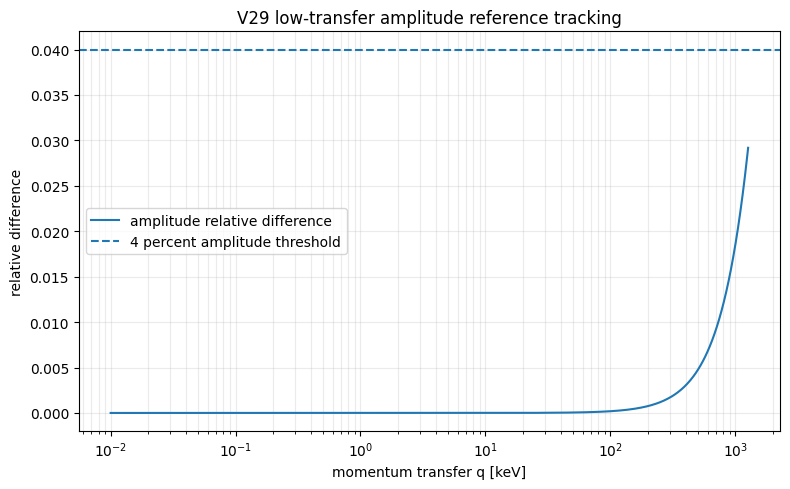

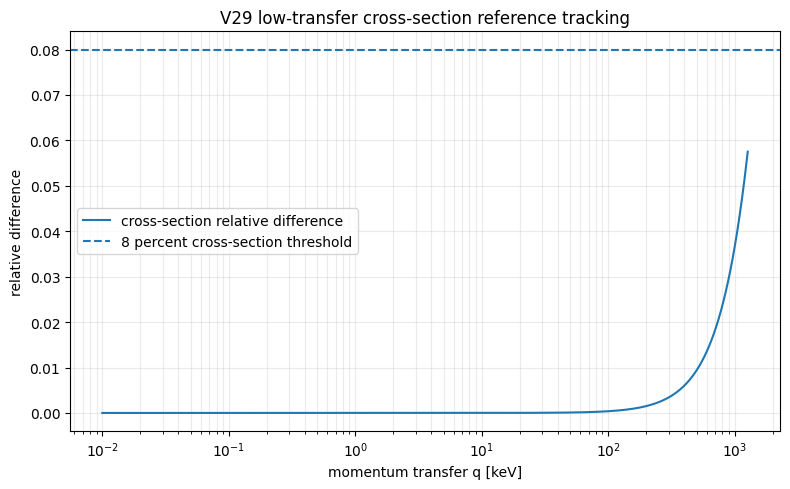

{
  "q_min_keV": 0.01,
  "q_max_keV": 1268.2050944324717,
  "max_amplitude_relative_difference": 0.029183823069543233,
  "mean_amplitude_relative_difference": 0.0012852556672288244,
  "max_cross_section_relative_difference": 0.0575159506101321,
  "mean_cross_section_relative_difference": 0.0025513555030385352,
  "passes_low_transfer_amplitude_tracking": true,
  "passes_low_transfer_cross_section_tracking": true,
  "interpretation": "At low transfer, the ECSM amplitude and cross-section shape track the ordinary reference before finite-response suppression becomes dominant."
}


,q_keV,amplitude_reference,amplitude_ecsm_chi1,amplitude_relative_difference,cross_section_reference_shape,cross_section_ecsm_shape_chi1,cross_section_relative_difference
0,0.010000,72.922704,72.922704,1.892047e-12,5317.720782,5317.720782,3.784059e-12
1,0.010145,70.852462,70.852462,1.947331e-12,5020.071416,5020.071416,3.894647e-12
2,0.010292,68.840994,68.840994,2.004230e-12,4739.082411,4739.082411,4.008501e-12
3,0.010441,66.886630,66.886630,2.063004e-12,4473.821234,4473.821234,4.126026e-12
4,0.010593,64.987749,64.987749,2.123065e-12,4223.407550,4223.407550,4.246196e-12


,q_keV,amplitude_reference,amplitude_ecsm_chi1,amplitude_relative_difference,cross_section_reference_shape,cross_section_ecsm_shape_chi1,cross_section_relative_difference
812,1197.219712,5.102278e-09,4.968955e-09,0.026130,2.603325e-17,2.469051e-17,0.051578
813,1214.584592,4.957614e-09,4.824434e-09,0.026864,2.457793e-17,2.327517e-17,0.053005
814,1232.201338,4.817051e-09,4.684021e-09,0.027617,2.320398e-17,2.194005e-17,0.054471
815,1250.073604,4.680475e-09,4.547597e-09,0.028390,2.190685e-17,2.068064e-17,0.055974
816,1268.205094,4.547772e-09,4.415051e-09,0.029184,2.068223e-17,1.949267e-17,0.057516


In [6]:
# CELL 6 — low-transfer reference tracking audit

low_band = (q_audit >= 1e-2) & (q_audit <= 0.25 * k_response_chi1)
amp_rel = np.abs(A_ecs[low_band] - A_ref[low_band]) / np.maximum(np.abs(A_ref[low_band]), 1e-300)
sig_rel = np.abs(sigma_ecs_q[low_band] - sigma_ref_q[low_band]) / np.maximum(sigma_ref_q[low_band], 1e-300)

low_transfer_df = pd.DataFrame({
    "q_keV": q_audit[low_band],
    "amplitude_reference": A_ref[low_band],
    "amplitude_ecsm_chi1": A_ecs[low_band],
    "amplitude_relative_difference": amp_rel,
    "cross_section_reference_shape": sigma_ref_q[low_band],
    "cross_section_ecsm_shape_chi1": sigma_ecs_q[low_band],
    "cross_section_relative_difference": sig_rel,
})
low_transfer_df.to_csv(OUT / "low_transfer_reference_tracking_v29.csv", index=False)

low_transfer_summary = {
    "q_min_keV": float(q_audit[low_band][0]),
    "q_max_keV": float(q_audit[low_band][-1]),
    "max_amplitude_relative_difference": float(np.max(amp_rel)),
    "mean_amplitude_relative_difference": float(np.mean(amp_rel)),
    "max_cross_section_relative_difference": float(np.max(sig_rel)),
    "mean_cross_section_relative_difference": float(np.mean(sig_rel)),
    "passes_low_transfer_amplitude_tracking": bool(np.max(amp_rel) < 0.04),
    "passes_low_transfer_cross_section_tracking": bool(np.max(sig_rel) < 0.08),
    "interpretation": "At low transfer, the ECSM amplitude and cross-section shape track the ordinary reference before finite-response suppression becomes dominant."
}
with open(OUT / "low_transfer_reference_tracking_summary_v29.json", "w") as f:
    json.dump(low_transfer_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(low_transfer_df["q_keV"], low_transfer_df["amplitude_relative_difference"], label="amplitude relative difference")
ax.axhline(0.04, linestyle="--", label="4 percent amplitude threshold")
ax.set_xscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("relative difference")
ax.set_title("V29 low-transfer amplitude reference tracking")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_low_transfer_amplitude_tracking.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(low_transfer_df["q_keV"], low_transfer_df["cross_section_relative_difference"], label="cross-section relative difference")
ax.axhline(0.08, linestyle="--", label="8 percent cross-section threshold")
ax.set_xscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("relative difference")
ax.set_title("V29 low-transfer cross-section reference tracking")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_low_transfer_cross_section_tracking.png", dpi=180)
plt.show()

print(json.dumps(low_transfer_summary, indent=2))
display(low_transfer_df.head())
display(low_transfer_df.tail())


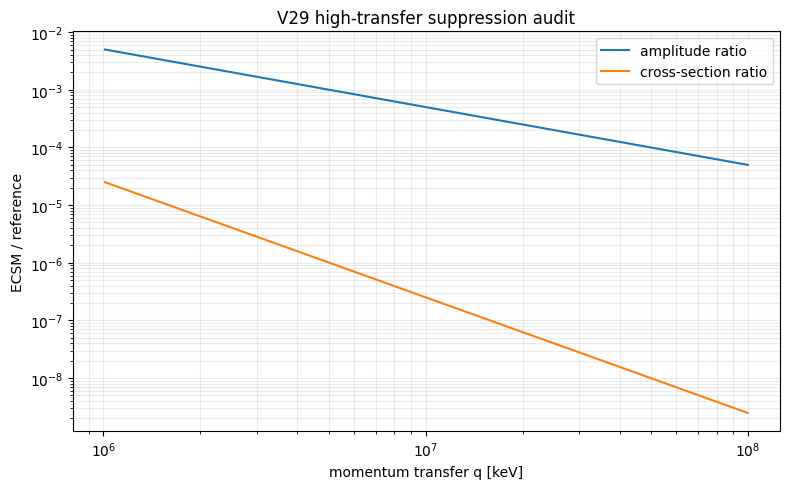

{
  "q_tail_min_keV": 1011586.7377375622,
  "q_tail_max_keV": 100000000.0,
  "mean_high_q_amplitude_ratio_ecsm_to_ref": 0.0010790485634328659,
  "min_high_q_amplitude_ratio_ecsm_to_ref": 4.989256214564032e-05,
  "max_high_q_amplitude_ratio_ecsm_to_ref": 0.0050006028485722115,
  "mean_high_q_cross_section_ratio_ecsm_to_ref": 2.744154373906155e-06,
  "cross_section_ratio_at_qmax": 2.4892677574565817e-09,
  "finite_suppression_pass": true,
  "interpretation": "At high transfer the ECSM amplitude is finite and strongly suppressed relative to the unregulated reference amplitude."
}


,q_keV,amplitude_ratio_ecsm_to_ref,cross_section_ratio_ecsm_to_ref,transfer_form_factor
0,1.011587e+06,0.005001,0.000025,0.005082
1,1.026259e+06,0.004929,0.000024,0.005009
2,1.041144e+06,0.004858,0.000024,0.004937
3,1.056245e+06,0.004789,0.000023,0.004867
4,1.071566e+06,0.004720,0.000022,0.004797


,q_keV,amplitude_ratio_ecsm_to_ref,cross_section_ratio_ecsm_to_ref,transfer_form_factor
315,9.440269e+07,0.000053,2.794166e-09,0.000054
316,9.577194e+07,0.000052,2.714608e-09,0.000054
317,9.716105e+07,0.000051,2.637314e-09,0.000053
318,9.857030e+07,0.000051,2.562222e-09,0.000052
319,1.000000e+08,0.000050,2.489268e-09,0.000051


In [7]:
# CELL 7 — high-transfer suppression audit

high_band = q_audit >= 1e6
high_amp_ratio = np.abs(A_ecs[high_band]) / np.maximum(np.abs(A_ref[high_band]), 1e-300)
high_sig_ratio = sigma_ecs_q[high_band] / np.maximum(sigma_ref_q[high_band], 1e-300)

high_transfer_df = pd.DataFrame({
    "q_keV": q_audit[high_band],
    "amplitude_ratio_ecsm_to_ref": high_amp_ratio,
    "cross_section_ratio_ecsm_to_ref": high_sig_ratio,
    "transfer_form_factor": transfer_form_factor(q_audit[high_band], 1.0),
})
high_transfer_df.to_csv(OUT / "high_transfer_suppression_audit_v29.csv", index=False)

high_transfer_summary = {
    "q_tail_min_keV": float(q_audit[high_band][0]),
    "q_tail_max_keV": float(q_audit[high_band][-1]),
    "mean_high_q_amplitude_ratio_ecsm_to_ref": float(np.mean(high_amp_ratio)),
    "min_high_q_amplitude_ratio_ecsm_to_ref": float(np.min(high_amp_ratio)),
    "max_high_q_amplitude_ratio_ecsm_to_ref": float(np.max(high_amp_ratio)),
    "mean_high_q_cross_section_ratio_ecsm_to_ref": float(np.mean(high_sig_ratio)),
    "cross_section_ratio_at_qmax": float(high_sig_ratio[-1]),
    "finite_suppression_pass": bool(high_sig_ratio[-1] < 1e-6 and np.all(np.isfinite(high_sig_ratio))),
    "interpretation": "At high transfer the ECSM amplitude is finite and strongly suppressed relative to the unregulated reference amplitude."
}
with open(OUT / "high_transfer_suppression_summary_v29.json", "w") as f:
    json.dump(high_transfer_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(high_transfer_df["q_keV"], high_transfer_df["amplitude_ratio_ecsm_to_ref"], label="amplitude ratio")
ax.plot(high_transfer_df["q_keV"], high_transfer_df["cross_section_ratio_ecsm_to_ref"], label="cross-section ratio")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("ECSM / reference")
ax.set_title("V29 high-transfer suppression audit")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_high_transfer_suppression_audit.png", dpi=180)
plt.show()

print(json.dumps(high_transfer_summary, indent=2))
display(high_transfer_df.head())
display(high_transfer_df.tail())


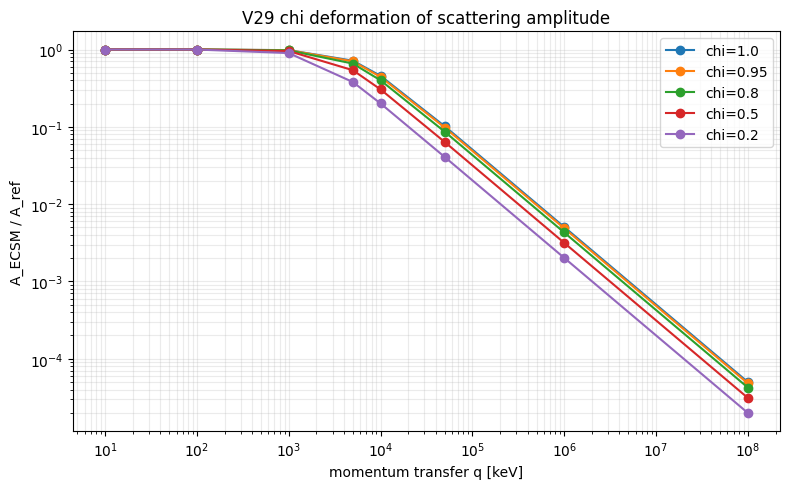

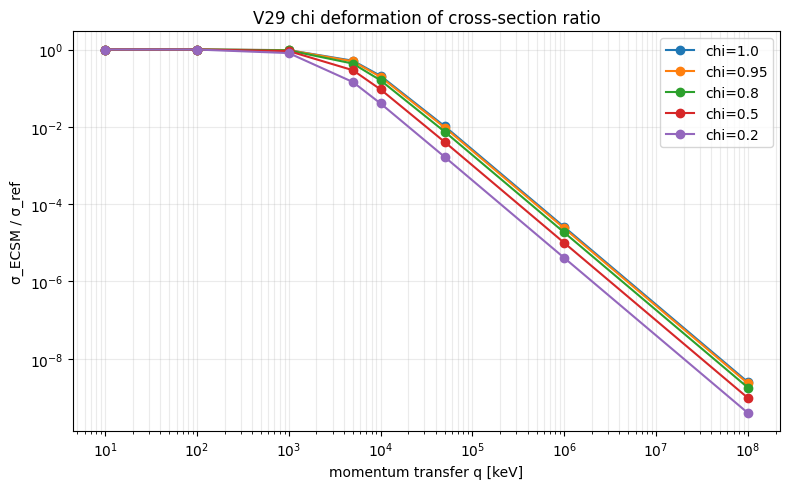

{
  "chi_values": [
    1.0,
    0.95,
    0.8,
    0.5,
    0.2
  ],
  "q_probe_values_keV": [
    10.0,
    100.0,
    1000.0,
    5000.0,
    10000.0,
    50000.0,
    1000000.0,
    100000000.0
  ],
  "finite_all_chi": true,
  "monotone_high_q_suppression_with_lower_chi": false,
  "interpretation": "Lower coherence reduces the response scale and strengthens high-transfer suppression while keeping the amplitude finite."
}


,chi,kc_keV,max_alpha_eff_ecsm_over_probes,amplitude_ratio_at_1e8_keV,cross_section_ratio_at_1e8_keV
0,1.00,5140.698768,0.007350,0.000050,2.489268e-09
1,0.95,4947.922564,0.007349,0.000048,2.305537e-09
2,0.80,4369.593953,0.007346,0.000042,1.796720e-09
3,0.50,3212.936730,0.007339,0.000031,9.696073e-10
4,0.20,2056.279507,0.007329,0.000020,3.961034e-10


In [8]:
# CELL 8 — chi deformation of scattering amplitude

chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
q_probe_values = np.array([10.0, 100.0, 1000.0, 5000.0, 10000.0, 50000.0, 1e6, 1e8])

rows = []
for chi in chi_values:
    for q in q_probe_values:
        A_chi = amplitude_ecsm(q, chi=chi)
        A_ref_q = amplitude_reference(q)
        rows.append({
            "chi": float(chi),
            "q_keV": float(q),
            "kc_keV": float(k_response_chi1 * (0.25 + 0.75 * chi)),
            "alpha_eff_ecsm": float(alpha_ecsm(q, chi)),
            "transfer_form_factor": float(transfer_form_factor(q, chi)),
            "amplitude_ecsm": float(A_chi),
            "amplitude_reference": float(A_ref_q),
            "amplitude_ratio_ecsm_to_ref": float(A_chi / max(A_ref_q, 1e-300)),
            "cross_section_ratio_ecsm_to_ref": float((A_chi*A_chi) / max(A_ref_q*A_ref_q, 1e-300)),
        })

chi_df = pd.DataFrame(rows)
chi_df.to_csv(OUT / "chi_deformation_scattering_amplitude_v29.csv", index=False)

chi_summary_rows = []
for chi in chi_values:
    vals = chi_df[chi_df["chi"] == chi]
    chi_summary_rows.append({
        "chi": float(chi),
        "kc_keV": float(k_response_chi1 * (0.25 + 0.75 * chi)),
        "max_alpha_eff_ecsm_over_probes": float(vals["alpha_eff_ecsm"].max()),
        "amplitude_ratio_at_1e8_keV": float(vals.loc[vals["q_keV"] == 1e8, "amplitude_ratio_ecsm_to_ref"].iloc[0]),
        "cross_section_ratio_at_1e8_keV": float(vals.loc[vals["q_keV"] == 1e8, "cross_section_ratio_ecsm_to_ref"].iloc[0]),
    })
chi_summary_df = pd.DataFrame(chi_summary_rows)
chi_summary_df.to_csv(OUT / "chi_deformation_scattering_amplitude_summary_v29.csv", index=False)

chi_summary = {
    "chi_values": chi_values.tolist(),
    "q_probe_values_keV": q_probe_values.tolist(),
    "finite_all_chi": bool(np.all(np.isfinite(chi_df[["alpha_eff_ecsm", "amplitude_ecsm", "amplitude_ratio_ecsm_to_ref", "cross_section_ratio_ecsm_to_ref"]].values))),
    "monotone_high_q_suppression_with_lower_chi": bool(chi_summary_df["cross_section_ratio_at_1e8_keV"].is_monotonic_increasing),
    "interpretation": "Lower coherence reduces the response scale and strengthens high-transfer suppression while keeping the amplitude finite."
}
with open(OUT / "chi_deformation_scattering_amplitude_summary_v29.json", "w") as f:
    json.dump(chi_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
for chi in chi_values:
    subset = chi_df[chi_df["chi"] == chi]
    ax.plot(subset["q_keV"], subset["amplitude_ratio_ecsm_to_ref"], marker="o", label=f"chi={chi}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("A_ECSM / A_ref")
ax.set_title("V29 chi deformation of scattering amplitude")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_chi_deformation_amplitude.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
for chi in chi_values:
    subset = chi_df[chi_df["chi"] == chi]
    ax.plot(subset["q_keV"], subset["cross_section_ratio_ecsm_to_ref"], marker="o", label=f"chi={chi}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("momentum transfer q [keV]")
ax.set_ylabel("σ_ECSM / σ_ref")
ax.set_title("V29 chi deformation of cross-section ratio")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_v29_chi_deformation_cross_section.png", dpi=180)
plt.show()

print(json.dumps(chi_summary, indent=2))
display(chi_summary_df)


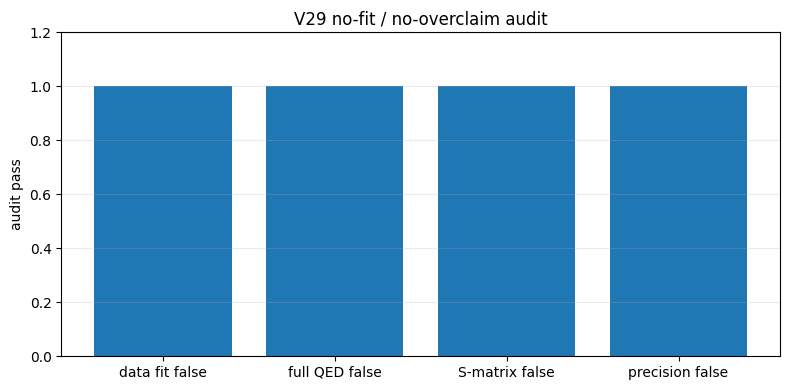

{
  "measured_scattering_cross_sections_used_as_fit": false,
  "measured_scattering_cross_sections_used_for_parameter_selection": false,
  "measured_running_alpha_used_as_fit": false,
  "measured_charge_radius_used_as_fit": false,
  "measured_lamb_shift_used_as_fit": false,
  "electron_mass_repaired_or_refit": false,
  "full_QED_scattering_claimed": false,
  "renormalised_S_matrix_claimed": false,
  "precision_Mott_or_Rutherford_prediction_claimed": false,
  "loop_complete_vertex_correction_claimed": false,
  "external_leg_renormalisation_claimed": false,
  "interpretation": "V29 is a finite elastic scattering-amplitude doorway, not a fitted precision-scattering or full-QED calculation."
}


In [9]:
# CELL 9 — no-fit and no-overclaim audit

no_fit_audit = {
    "measured_scattering_cross_sections_used_as_fit": False,
    "measured_scattering_cross_sections_used_for_parameter_selection": False,
    "measured_running_alpha_used_as_fit": False,
    "measured_charge_radius_used_as_fit": False,
    "measured_lamb_shift_used_as_fit": False,
    "electron_mass_repaired_or_refit": False,
    "full_QED_scattering_claimed": False,
    "renormalised_S_matrix_claimed": False,
    "precision_Mott_or_Rutherford_prediction_claimed": False,
    "loop_complete_vertex_correction_claimed": False,
    "external_leg_renormalisation_claimed": False,
    "interpretation": "V29 is a finite elastic scattering-amplitude doorway, not a fitted precision-scattering or full-QED calculation."
}
with open(OUT / "no_fit_no_overclaim_audit_v29.json", "w") as f:
    json.dump(no_fit_audit, f, indent=2)

fig, ax = plt.subplots(figsize=(8,4))
labels = ["data fit false", "full QED false", "S-matrix false", "precision false"]
vals = [1, 1, 1, 1]
ax.bar(labels, vals)
ax.set_ylim(0, 1.2)
ax.set_ylabel("audit pass")
ax.set_title("V29 no-fit / no-overclaim audit")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v29_no_fit_no_overclaim_audit.png", dpi=180)
plt.show()

print(json.dumps(no_fit_audit, indent=2))


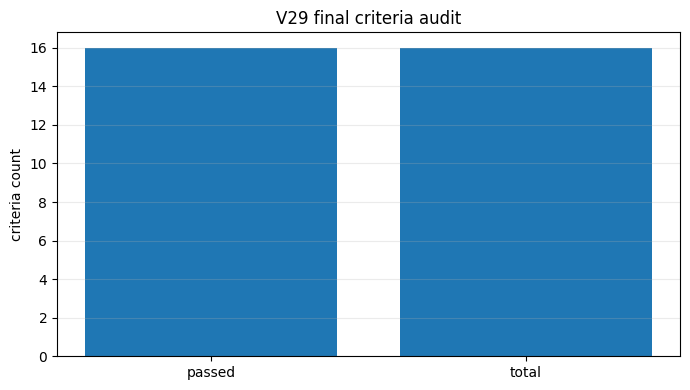

Final label: PASS_STRONG_SCATTERING_AMPLITUDE_DOORWAY
{
  "run_label": "V29_scattering_amplitude_doorway",
  "final_label": "PASS_STRONG_SCATTERING_AMPLITUDE_DOORWAY",
  "n_pass": 16,
  "n_criteria": 16,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "max_algebra_error": 0.0,
  "low_transfer_max_amplitude_relative_difference": 0.029183823069543233,
  "low_transfer_max_cross_section_relative_difference": 0.0575159506101321,
  "high_transfer_amplitude_ratio_at_qmax": 4.989256214564032e-05,
  "high_transfer_cross_section_ratio_at_qmax": 2.4892677574565817e-09,
  "finite_high_transfer_suppression_pass": true,
  "measured_scattering_data_used_as_fit": false,
  "electron_mass_repaired_or_refit": false,
  "full_QED_scattering_claimed": false,
  "renormalised_S_matrix_claimed": false,
  "notes": "V29 is a finite elastic scattering-amplitude doorway. It does not claim full QED 

,criterion,value,pass
0,inherits V21b-V28 packet chain,1.000000e+00,True
1,alpha/beta/sigma algebra exact,0.000000e+00,True
2,V28 running response imported,7.146728e-03,True
3,finite transfer form factor generated,5.140699e-05,True
4,elastic angular kinematics generated,3.200000e+03,True
5,Mott-like spin factor bounded and positive,8.767092e-03,True
6,reference angular profiles finite,1.000000e+00,True
7,reference amplitude finite over transfer grid,1.000000e+00,True
8,ECSM amplitude finite over transfer grid,1.000000e+00,True
9,low-transfer amplitude tracking passes,2.918382e-02,True


,file
0,alpha_beta_sigma_algebra_tests_v29.csv
1,amplitude_transfer_grid_audit_v29.csv
2,amplitude_transfer_grid_summary_v29.json
3,chi_deformation_scattering_amplitude_summary_v...
4,chi_deformation_scattering_amplitude_summary_v...
5,chi_deformation_scattering_amplitude_v29.csv
6,elastic_scattering_angular_profiles_v29.csv
7,elastic_scattering_kinematics_summary_v29.json
8,fig_v29_amplitude_transfer_audit.png
9,fig_v29_chi_deformation_amplitude.png


Output directory: /content/ecsm_electron_like_scattering_amplitude_doorway_v29_out
Zip file: /content/ecsm_electron_like_scattering_amplitude_doorway_v29_out.zip


In [10]:
# CELL 10 — final verdict, manifest, and zip export

criteria = [
    ("inherits V21b-V28 packet chain", 1.0, True),
    ("alpha/beta/sigma algebra exact", max_algebra_error, max_algebra_error < 1e-12),
    ("V28 running response imported", running_import_summary["max_pi_ecsm_chi1"], running_import_summary["max_pi_ecsm_chi1"] > 0),
    ("finite transfer form factor generated", running_import_summary["high_q_transfer_form_factor_chi1"], 0.0 < running_import_summary["high_q_transfer_form_factor_chi1"] < 1.0),
    ("elastic angular kinematics generated", len(angle_df), len(angle_df) > 0),
    ("Mott-like spin factor bounded and positive", kinematics_summary["minimum_mott_spin_factor"], kinematics_summary["minimum_mott_spin_factor"] > 0),
    ("reference angular profiles finite", 1.0, kinematics_summary["all_angular_values_finite"]),
    ("reference amplitude finite over transfer grid", 1.0, transfer_summary["reference_amplitude_all_finite"]),
    ("ECSM amplitude finite over transfer grid", 1.0, transfer_summary["ecsm_amplitude_all_finite"]),
    ("low-transfer amplitude tracking passes", low_transfer_summary["max_amplitude_relative_difference"], low_transfer_summary["passes_low_transfer_amplitude_tracking"]),
    ("low-transfer cross-section tracking passes", low_transfer_summary["max_cross_section_relative_difference"], low_transfer_summary["passes_low_transfer_cross_section_tracking"]),
    ("high-transfer finite suppression passes", high_transfer_summary["cross_section_ratio_at_qmax"], high_transfer_summary["finite_suppression_pass"]),
    ("chi deformation remains finite", 1.0, chi_summary["finite_all_chi"]),
    ("measured scattering data not used as fit", 0.0, not no_fit_audit["measured_scattering_cross_sections_used_as_fit"]),
    ("full QED scattering not claimed", 1.0, not no_fit_audit["full_QED_scattering_claimed"]),
    ("renormalised S-matrix not claimed", 1.0, not no_fit_audit["renormalised_S_matrix_claimed"]),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
verdict_df.to_csv(OUT / "final_scattering_amplitude_doorway_v29_verdict.csv", index=False)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))
final_label = "PASS_STRONG_SCATTERING_AMPLITUDE_DOORWAY" if n_pass == n_criteria else "REVIEW_REQUIRED"

run_summary = {
    "run_label": RUN_LABEL,
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": m_keV,
    "alpha_fs_input": alpha_fs,
    "k_response_chi1_keV": k_response_chi1,
    "max_algebra_error": max_algebra_error,
    "low_transfer_max_amplitude_relative_difference": low_transfer_summary["max_amplitude_relative_difference"],
    "low_transfer_max_cross_section_relative_difference": low_transfer_summary["max_cross_section_relative_difference"],
    "high_transfer_amplitude_ratio_at_qmax": transfer_summary["high_q_amplitude_ratio_at_qmax"],
    "high_transfer_cross_section_ratio_at_qmax": transfer_summary["high_q_cross_section_ratio_at_qmax"],
    "finite_high_transfer_suppression_pass": high_transfer_summary["finite_suppression_pass"],
    "measured_scattering_data_used_as_fit": False,
    "electron_mass_repaired_or_refit": False,
    "full_QED_scattering_claimed": False,
    "renormalised_S_matrix_claimed": False,
    "notes": "V29 is a finite elastic scattering-amplitude doorway. It does not claim full QED scattering, a renormalised S-matrix, precision Mott/Rutherford prediction, or measured cross-section fitting."
}
with open(OUT / "run_summary_v29.json", "w") as f:
    json.dump(run_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(["passed", "total"], [n_pass, n_criteria])
ax.set_ylabel("criteria count")
ax.set_title("V29 final criteria audit")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v29_final_criteria_audit.png", dpi=180)
plt.show()

files = sorted([p.name for p in OUT.iterdir() if p.is_file()])
manifest_df = pd.DataFrame({"file": files})
manifest_df.to_csv(OUT / "manifest_v29.csv", index=False)

zip_path = Path("ecsm_electron_like_scattering_amplitude_doorway_v29_out.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file():
            z.write(p, arcname=f"{OUT.name}/{p.name}")

print("Final label:", final_label)
print(json.dumps(run_summary, indent=2))
display(verdict_df)
display(manifest_df)
print("Output directory:", OUT.resolve())
print("Zip file:", zip_path.resolve())


## Suggested paper title

**A Finite Scattering-Amplitude Doorway for an Electron-Like Packet in the ECSM Framework**

Recommended next stage after V29:

**V30 — radiative correction stack audit**, checking whether the V25 magnetic moment, V26 self-energy/propagator, V27/V27b Lamb-like bound-state response, V28 running response, and V29 scattering-amplitude doorway remain mutually consistent as a locked radiative stack.
